In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

In [3]:
!python -V

Python 3.13.15


In [4]:
#Importar el dataset sobre gasolinas
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/autompg-dataset")

print("Path to dataset files:", path)




Using Colab cache for faster access to the 'autompg-dataset' dataset.
Path to dataset files: /kaggle/input/autompg-dataset


In [5]:
#importar de verdad desde el path

df = pd.read_csv(path + "/auto-mpg.csv")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [6]:
# Revisar si hay nulos
df.isna().sum()


,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [7]:
# Eliminar la columna de car name
if 'car name' in df.columns:
    df = df.drop(columns=['car name'])


In [8]:
# Convertir horsepower a float
if 'horsepower' in df.columns:
    df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
    df = df.dropna(subset=['horsepower'])


In [9]:
# buscar en horsepower los valores = "?" y reemplazarlos por la media
if 'horsepower' in df.columns:
    print('Valores "?" en horsepower:', df['horsepower'].isin(['?']).sum())
    media_horsepower = pd.to_numeric(df.loc[df['horsepower'] != '?', 'horsepower'], errors='coerce').mean()
    df['horsepower'] = df['horsepower'].replace('?', np.nan)
    df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
    df['horsepower'] = df['horsepower'].fillna(media_horsepower)


Valores "?" en horsepower: 0


In [10]:
# Definir las variables de entrada y salida a partir del DataFrame
X = df.drop(columns=['mpg'])
y = df['mpg']

# Dividir los datos en 80% para entrenar y 20% para testear (X, y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


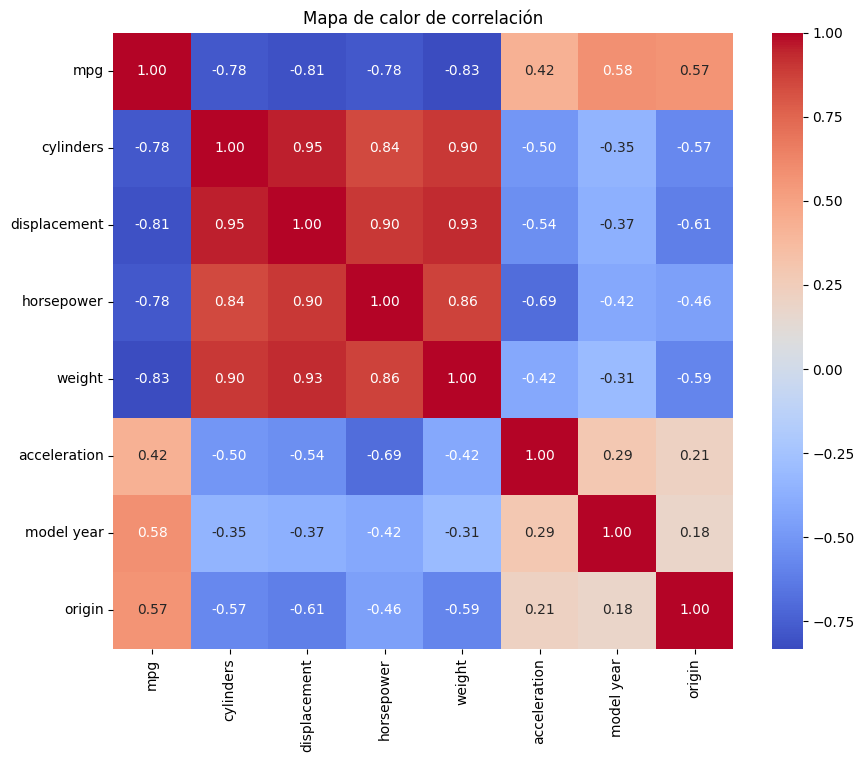

In [11]:
# Hacer un mapa de calor con seaborn para ver la correlación entre las variables
plt.figure(figsize=(10, 8))
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de calor de correlación')
plt.show()


In [12]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,1
1,15.0,8,350.0,165.0,3693,11.5,70,1
2,18.0,8,318.0,150.0,3436,11.0,70,1
3,16.0,8,304.0,150.0,3433,12.0,70,1
4,17.0,8,302.0,140.0,3449,10.5,70,1


In [13]:
# Normalizar X_train usando StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled)


[[ 0.30486156  0.28457757  0.14142863 ...  1.1217589   0.49452752
  -0.68982474]
 [-0.87318372 -0.53588042 -0.32949862 ... -0.22893966 -0.0572982
  -0.68982474]
 [ 0.30486156 -0.23665456 -0.19868549 ... -0.37111846 -0.33321105
  -0.68982474]
 ...
 [-0.87318372 -0.4297035  -0.51263699 ...  0.73076722  0.49452752
  -0.68982474]
 [-0.87318372 -0.94128319 -1.0358895  ...  1.83265289  1.32226608
  -0.68982474]
 [ 1.48290683  1.97375578  1.18793363 ... -0.54884195 -0.88503677
  -0.68982474]]


In [14]:
# Creacion del modelo secuencial de regresion lineal
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)))
model.add(tf.keras.layers.Dense(32, activation='relu'))
model.add(tf.keras.layers.Dense(16, activation='relu'))
model.add(tf.keras.layers.Dense(8, activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='linear'))




In [15]:
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.005),
            loss='mse',
            metrics=['mae'])


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

Ahora a entrenar el modelo

NOTA IMPORTANTE:

REINICIAR EL ENTORNO PARA BORRAR LA "CACHE" 
Estas variables de antes alteran el modelo y dan resultados peores.
Toca reiniciar la sesion y ejecutar todo desde 0


In [17]:
history=model.fit(X_train_scaled, y_train, epochs=500, batch_size=32, validation_split=0.2, verbose=2)

Epoch 1/500
8/8 - 5s - 568ms/step - loss: 600.8345 - mae: 23.2288 - val_loss: 660.8151 - val_mae: 24.5524
Epoch 2/500
8/8 - 1s - 159ms/step - loss: 546.8971 - mae: 22.1415 - val_loss: 548.0975 - val_mae: 22.3752
Epoch 3/500
8/8 - 0s - 13ms/step - loss: 391.0361 - mae: 18.6599 - val_loss: 297.0158 - val_mae: 16.4107
Epoch 4/500
8/8 - 0s - 13ms/step - loss: 162.9298 - mae: 11.6325 - val_loss: 91.6860 - val_mae: 7.9008
Epoch 5/500
8/8 - 0s - 13ms/step - loss: 56.1808 - mae: 6.1570 - val_loss: 54.6527 - val_mae: 5.8983
Epoch 6/500
8/8 - 0s - 13ms/step - loss: 39.4685 - mae: 5.0595 - val_loss: 41.3290 - val_mae: 5.0346
Epoch 7/500
8/8 - 0s - 14ms/step - loss: 30.0873 - mae: 4.3853 - val_loss: 30.7014 - val_mae: 4.2259
Epoch 8/500
8/8 - 0s - 13ms/step - loss: 23.4225 - mae: 3.8798 - val_loss: 23.7248 - val_mae: 3.6412
Epoch 9/500
8/8 - 0s - 13ms/step - loss: 18.0647 - mae: 3.3051 - val_loss: 17.3473 - val_mae: 2.9783
Epoch 10/500
8/8 - 0s - 13ms/step - loss: 15.3498 - mae: 3.0476 - val_loss:

KeyboardInterrupt: 

El analisis de la grafica ayuda a definir la cantidad optima de epocas 

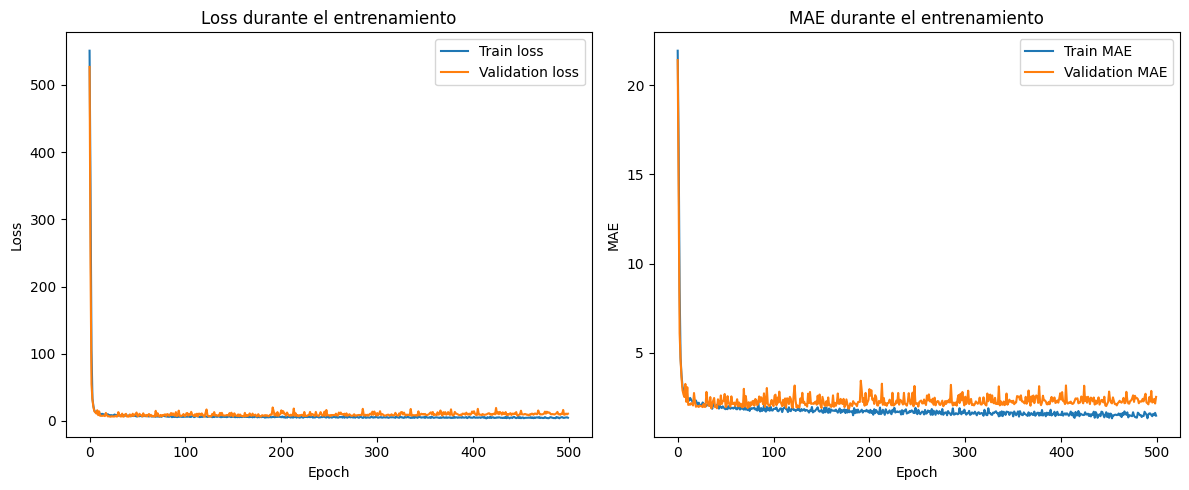

In [ ]:
# Graficar la variable loss y mae del entrenamiento y validación
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Loss durante el entrenamiento')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('MAE durante el entrenamiento')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()


El comportamiento optimo del modelo es cuando naranja y azul son iguales, cual varian es cuando el modelo esta sub o sobre entrenado, por lo tanto, en un aprox de 80-90 serian las epocas optimas

In [ ]:
# Darle persistencia al modelo guardandolo en .keras en la carpeta Redes densas
import os

ruta_carpeta = r'c:\Users\juana\Apuntes-Ciencia-de-Datos\Redes densas'
os.makedirs(ruta_carpeta, exist_ok=True)

ruta_modelo = os.path.join(ruta_carpeta, 'model_regresion_gasolina.keras')
model.save(ruta_modelo)
print('Modelo guardado en:', ruta_modelo)


Modelo guardado en: c:\Users\juana\Apuntes-Ciencia-de-Datos\Redes densas/model_regresion_gasolina.keras


In [ ]:
print(os.getcwd())
print(os.path.exists(ruta_carpeta))

/content
True


/adiacla/

In [ ]:
#1. Entrenar el modelo con una variable de E epocas, siendo E una variable definida al principio del codigo
#2. Que durante el entrenamiento una funcion valla tomando los valores de perdida y error de cada epoca
#3. Que esta funcion juzgue valor por valor y pueda identificar cuando estos valores indiquen que el modelo esta sobreajustando y pueda detener el entrenamiento de manera temprana
#4. Que al final del entrenamiento se pueda graficar la variable loss y mae del entrenamiento y validación

# ---- Variables de control ----
E = 200
PATIENCE = 15
MIN_DELTA = 1e-4
OVERFIT_RATIO = 1.10

# ---- Callback para detectar sobreajuste y detener temprano ----
class EarlyStoppingOverfit(tf.keras.callbacks.Callback):
    def __init__(self, patience=15, min_delta=1e-4, overfit_ratio=1.10):
        super().__init__()
        self.patience = patience
        self.min_delta = min_delta
        self.overfit_ratio = overfit_ratio
        self.wait = 0
        self.prev_train_loss = None
        self.prev_val_loss = None
        self.prev_train_mae = None
        self.prev_val_mae = None

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        train_loss = float(logs.get('loss', 0.0))
        val_loss = float(logs.get('val_loss', 0.0))
        train_mae = float(logs.get('mae', 0.0))
        val_mae = float(logs.get('val_mae', 0.0))

        if self.prev_train_loss is not None:
            train_improving = train_loss < self.prev_train_loss - self.min_delta
            val_worsening = val_loss > self.prev_val_loss + self.min_delta
            mae_worsening = val_mae > self.prev_val_mae + self.min_delta

            if train_improving and (val_worsening or mae_worsening) and val_loss > train_loss * self.overfit_ratio:
                self.wait += 1
                print(f"\nÉpoca {epoch + 1}: posible sobreajuste detectado ({self.wait}/{self.patience})")
            else:
                self.wait = 0

            if self.wait >= self.patience:
                print(f"\nEntrenamiento detenido temprano en la época {epoch + 1} por sobreajuste.")
                self.model.stop_training = True

        self.prev_train_loss = train_loss
        self.prev_val_loss = val_loss
        self.prev_train_mae = train_mae
        self.prev_val_mae = val_mae


# ---- Entrenamiento del modelo ----
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=E,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    callbacks=[EarlyStoppingOverfit(patience=PATIENCE, min_delta=MIN_DELTA, overfit_ratio=OVERFIT_RATIO)],
    verbose=2
)

# ---- Graficar loss y mae del entrenamiento y validación ----
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Loss durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('MAE durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Epocas entrenadas: {len(history.history['loss'])}")
print(f"Loss final entrenamiento: {history.history['loss'][-1]:.4f}")
print(f"Loss final validación: {history.history['val_loss'][-1]:.4f}")
print(f"MAE final entrenamiento: {history.history['mae'][-1]:.4f}")
print(f"MAE final validación: {history.history['val_mae'][-1]:.4f}")